## Imports and Setup

In [198]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
#import pooch
import scanpy as sc

## Data Loading and Prep

In [199]:
import scanpy as sc
import cellxgene_census

print("scanpy:", sc.__version__)

with cellxgene_census.open_soma() as census:
    print("Census build date:", census["census_info"]["summary"].read().concat().to_pandas()
          .set_index("label").loc["census_schema_version", "value"])

/var/folders/28/qcdth7n53477gw89dj3cp9dc0000gn/T/ipykernel_57983/1103102948.py:4: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)
The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


scanpy: 1.11.5
Census build date: 2.4.0


In [200]:
adata = sc.datasets.pbmc3k()

In [201]:
len(adata)

2700

## Quality Control

In [202]:
adata.var['mt'] = adata.var_names.str.startswith("MT-")
adata.var['ribo'] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var['hb'] = adata.var_names.str.startswith("^HB[^(P)]")


In [203]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], inplace=True, log1p=True)

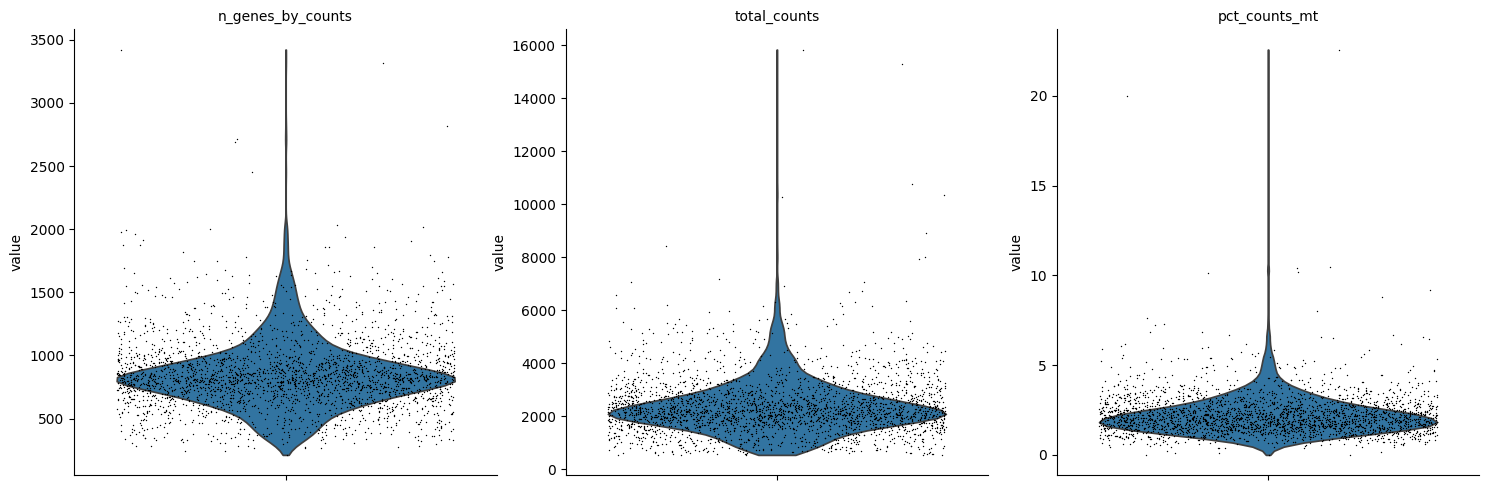

In [204]:
sc.pl.violin(adata,
             ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
             jitter=0.4, 
             multi_panel=True,
              )

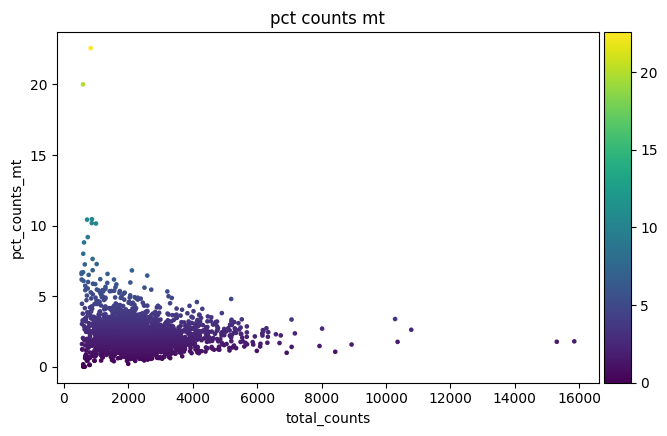

In [205]:
sc.pl.scatter(adata, "total_counts", "pct_counts_mt", color="pct_counts_mt")

In [206]:
mask = (
    (adata.obs['n_genes_by_counts'] >= 200) &
    (adata.obs['n_genes_by_counts'] <= 2500) &
    (adata.obs['pct_counts_mt']<=5)
)
adata = adata[mask]

In [207]:
len(adata)

2638

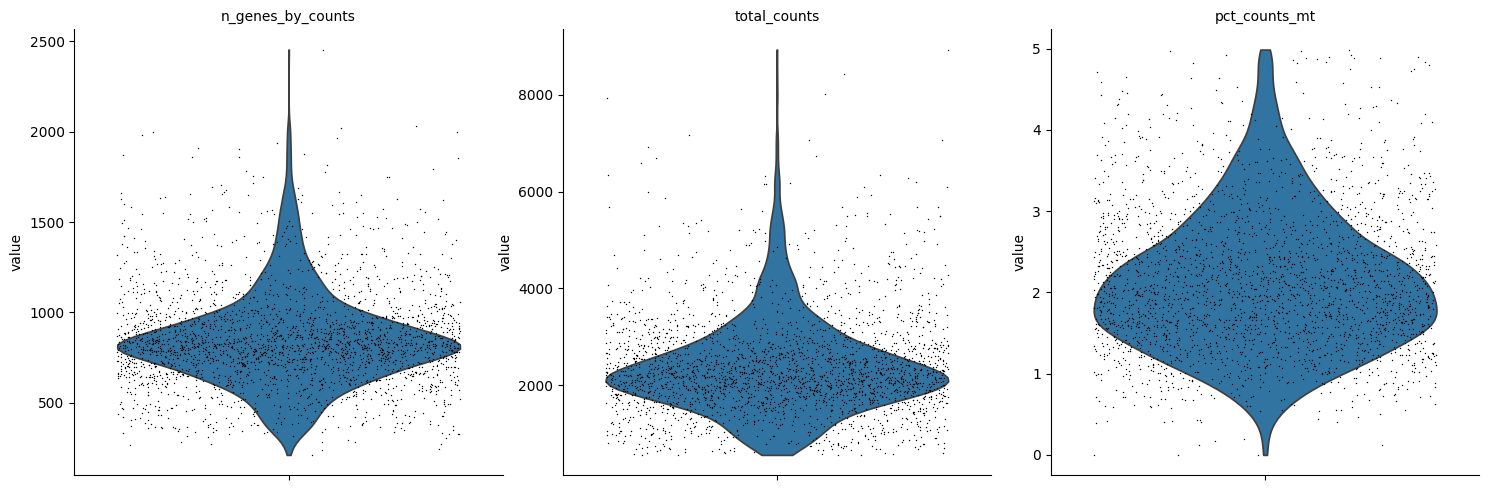

In [208]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

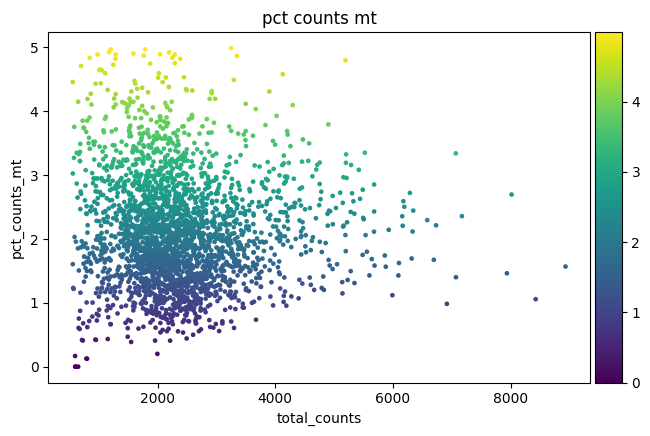

In [209]:
sc.pl.scatter(adata, 'total_counts', 'pct_counts_mt', color="pct_counts_mt")

## Normalization and Highly Variable Genes

In [210]:
adata.layers['counts'] = adata.X.copy()

/var/folders/28/qcdth7n53477gw89dj3cp9dc0000gn/T/ipykernel_57983/1155977868.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers['counts'] = adata.X.copy()


In [211]:
print('Before normalization', adata.X[0].sum())
sc.pp.normalize_total(adata, 1e4)
print('After normalization', adata.X[0].sum())
print('Before log scaling', adata.X.max())
sc.pp.log1p(adata)
print('After log scaling', adata.X.max())


Before normalization 2421.0
After normalization 9999.999
Before log scaling 1751.0548
After log scaling 7.4685445


/var/folders/28/qcdth7n53477gw89dj3cp9dc0000gn/T/ipykernel_57983/633088215.py:2: FutureWarning: The specified parameters ('target_sum',) are no longer positional. Please specify them like `target_sum=10000.0`
  sc.pp.normalize_total(adata, 1e4)


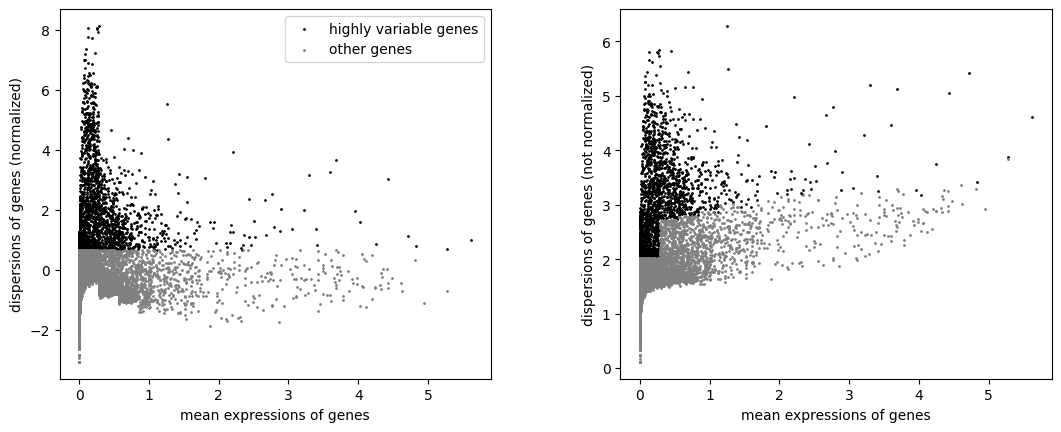

In [212]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pl.highly_variable_genes(adata)
adata.raw = adata
adata = adata[:, adata.var.highly_variable]


## PCA

In [215]:
sc.tl.pca(adata)
adata.obsm["X_pca"].shape


(2638, 50)

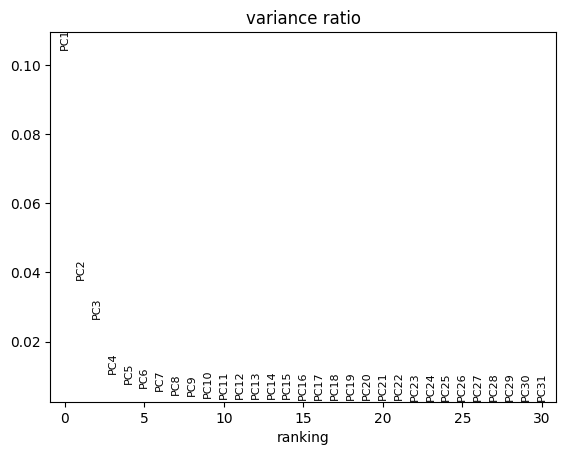

In [216]:
sc.pl.pca_variance_ratio(adata)

In [217]:
sc.pp.neighbors(adata, n_pcs=10)
adata.obsp["connectivities"]
adata.obsp["distances"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36932 stored elements and shape (2638, 2638)>